# Step 1: Import Required Libraries

In [2]:
# Core data handling libraries
import numpy as np
import pandas as pd

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and preprocessing libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Set visualization style
sns.set(style="whitegrid")


# Step 2: Load the Dataset

In [3]:
# Load the dataset
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

# Display basic information about the dataset
df.head(10)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [4]:
# Check dataset dimensions
print("Dataset Shape:", df.shape)

# Get detailed information about columns and data types
df.info()


Dataset Shape: (374, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ 

# Step 3: Initial Data Inspection & Data Quality Checks

In [5]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values per Column:\n", missing_values)

# Check for duplicate records
duplicate_count = df.duplicated().sum()
print("\nNumber of duplicate rows:", duplicate_count)

# Generate summary statistics for numerical features
df.describe()


Missing Values per Column:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Number of duplicate rows: 0


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


# Step 4: Data Cleaning & Column Standardization

In [6]:
# Create a copy of the dataset to preserve the original data
df_cleaned = df.copy()

# Standardize column names (remove spaces and make lowercase)
df_cleaned.columns = df_cleaned.columns.str.strip().str.lower().str.replace(' ', '_')

# Display updated column names
df_cleaned.columns


Index(['person_id', 'gender', 'age', 'occupation', 'sleep_duration',
       'quality_of_sleep', 'physical_activity_level', 'stress_level',
       'bmi_category', 'blood_pressure', 'heart_rate', 'daily_steps',
       'sleep_disorder'],
      dtype='object')

In [7]:
# Remove duplicate rows if any exist
df_cleaned = df_cleaned.drop_duplicates()

# Verify duplicates are removed
print("Duplicate rows after removal:", df_cleaned.duplicated().sum())


Duplicate rows after removal: 0


In [8]:
df_cleaned = df_cleaned.dropna(subset=['sleep_disorder'])


In [9]:
# Check missing values again
df_cleaned.isnull().sum()


person_id                  0
gender                     0
age                        0
occupation                 0
sleep_duration             0
quality_of_sleep           0
physical_activity_level    0
stress_level               0
bmi_category               0
blood_pressure             0
heart_rate                 0
daily_steps                0
sleep_disorder             0
dtype: int64

# Step 5: Feature Engineering

## 5.1 Splitting Blood Pressure into Systolic & Diastolic

In [10]:
# Split blood pressure into systolic and diastolic values
df_cleaned[['systolic_bp', 'diastolic_bp']] = df_cleaned['blood_pressure'].str.split('/', expand=True)

# Convert the new columns to numeric
df_cleaned['systolic_bp'] = df_cleaned['systolic_bp'].astype(int)
df_cleaned['diastolic_bp'] = df_cleaned['diastolic_bp'].astype(int)

# Drop the original blood_pressure column
df_cleaned.drop(columns=['blood_pressure'], inplace=True)

df_cleaned.head()


,person_id,gender,age,occupation,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,heart_rate,daily_steps,sleep_disorder,systolic_bp,diastolic_bp
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,140,90
16,17,Female,29,Nurse,6.5,5,40,7,Normal Weight,80,4000,Sleep Apnea,132,87


## 5.2 Encoding Categorical Features

In [11]:
# Initialize Label Encoder
le = LabelEncoder()

# Encode binary categorical feature
df_cleaned['gender'] = le.fit_transform(df_cleaned['gender'])

# Encode target variable
df_cleaned['sleep_disorder'] = le.fit_transform(df_cleaned['sleep_disorder'])

df_cleaned[['gender', 'sleep_disorder']].head()


,gender,sleep_disorder
3,1,1
4,1,1
5,1,0
6,1,0
16,0,1


## 5.3 One-Hot Encoding for Nominal Features

In [12]:
# One-hot encode nominal categorical features
df_cleaned = pd.get_dummies(
    df_cleaned,
    columns=['occupation', 'bmi_category'],
    drop_first=True
)

df_cleaned.head()


,person_id,gender,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,heart_rate,daily_steps,sleep_disorder,...,occupation_Lawyer,occupation_Nurse,occupation_Sales Representative,occupation_Salesperson,occupation_Scientist,occupation_Software Engineer,occupation_Teacher,bmi_category_Normal Weight,bmi_category_Obese,bmi_category_Overweight
3,4,1,28,5.9,4,30,8,85,3000,1,...,False,False,True,False,False,False,False,False,True,False
4,5,1,28,5.9,4,30,8,85,3000,1,...,False,False,True,False,False,False,False,False,True,False
5,6,1,28,5.9,4,30,8,85,3000,0,...,False,False,False,False,False,True,False,False,True,False
6,7,1,29,6.3,6,40,7,82,3500,0,...,False,False,False,False,False,False,True,False,True,False
16,17,0,29,6.5,5,40,7,80,4000,1,...,False,True,False,False,False,False,False,True,False,False


## 5.4 Feature Distribution Visualization

C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


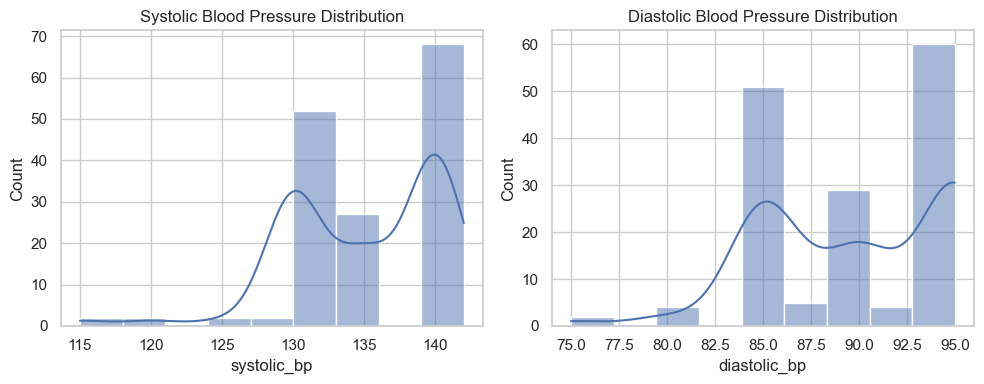

In [13]:
# Visualize systolic and diastolic blood pressure distributions
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_cleaned['systolic_bp'], kde=True)
plt.title("Systolic Blood Pressure Distribution")

plt.subplot(1,2,2)
sns.histplot(df_cleaned['diastolic_bp'], kde=True)
plt.title("Diastolic Blood Pressure Distribution")

plt.tight_layout()
plt.show()


# Step 6: Exploratory Data Analysis (EDA)

## 6.1 Sleep Disorder Distribution

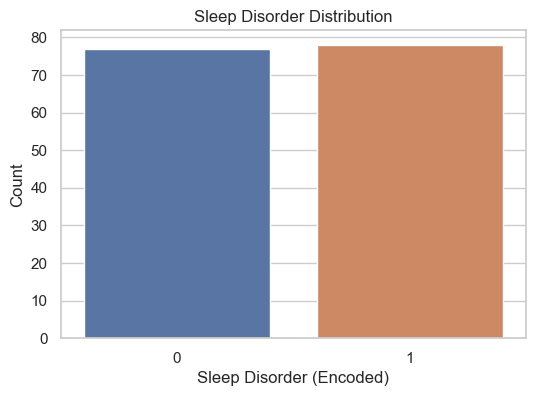

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='sleep_disorder', data=df_cleaned)
plt.title("Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder (Encoded)")
plt.ylabel("Count")
plt.show()


## 6.2 Gender vs Sleep Disorder

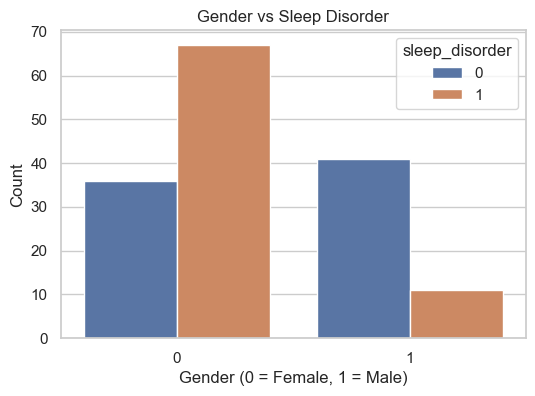

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='sleep_disorder', data=df_cleaned)
plt.title("Gender vs Sleep Disorder")
plt.xlabel("Gender (0 = Female, 1 = Male)")
plt.ylabel("Count")
plt.show()


## 6.3 Age vs Sleep Disorder

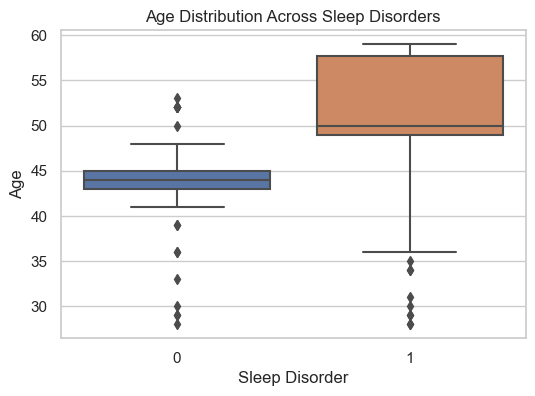

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sleep_disorder', y='age', data=df_cleaned)
plt.title("Age Distribution Across Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Age")
plt.show()


## 6.4 Occupation vs Sleep Disorder

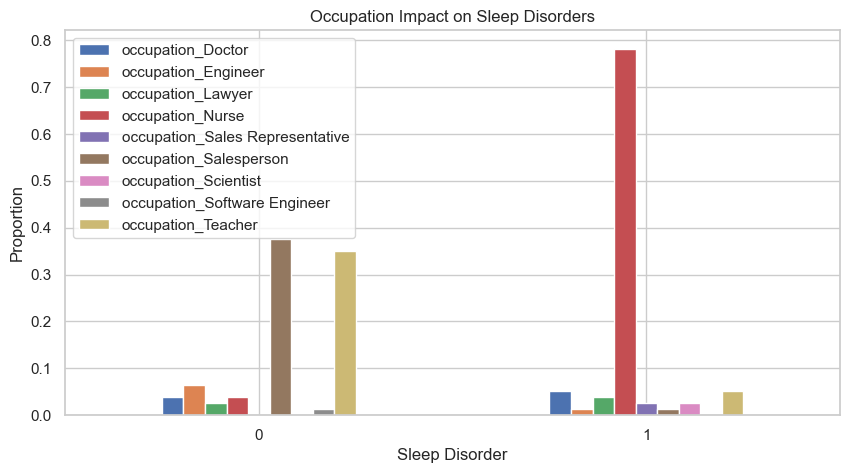

In [17]:
occupation_cols = [col for col in df_cleaned.columns if col.startswith('occupation_')]

occupation_disorder = df_cleaned.groupby('sleep_disorder')[occupation_cols].mean()

occupation_disorder.plot(kind='bar', figsize=(10,5))
plt.title("Occupation Impact on Sleep Disorders")
plt.xlabel("Sleep Disorder")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.show()


## 6.5 Lifestyle Factors vs Sleep Disorder

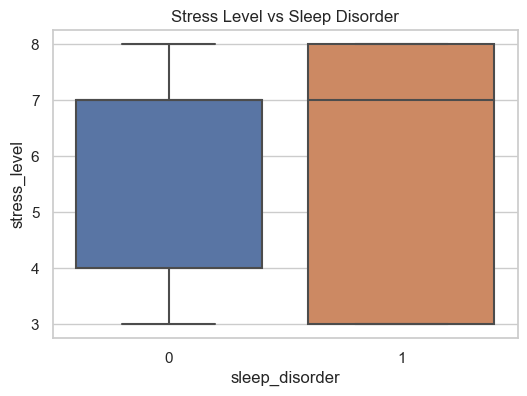

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='sleep_disorder', y='stress_level', data=df_cleaned)
plt.title("Stress Level vs Sleep Disorder")
plt.show()


## Physical Activity

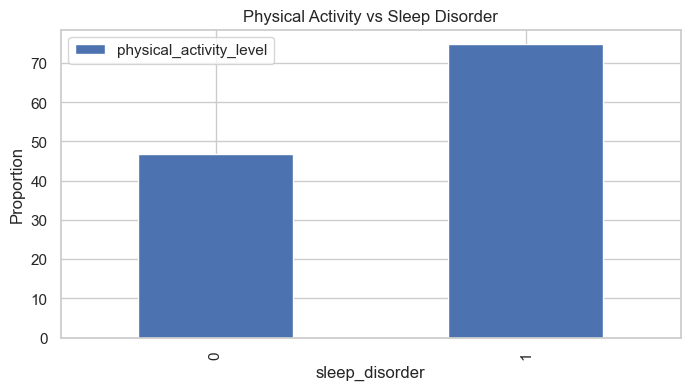

In [19]:
activity_cols = [col for col in df_cleaned.columns if col.startswith('physical_activity_')]

df_cleaned.groupby('sleep_disorder')[activity_cols].mean().plot(
    kind='bar', figsize=(8,4)
)
plt.title("Physical Activity vs Sleep Disorder")
plt.ylabel("Proportion")
plt.show()


## 6.6 BMI Category & Cardiovascular Indicators

### BMI Category

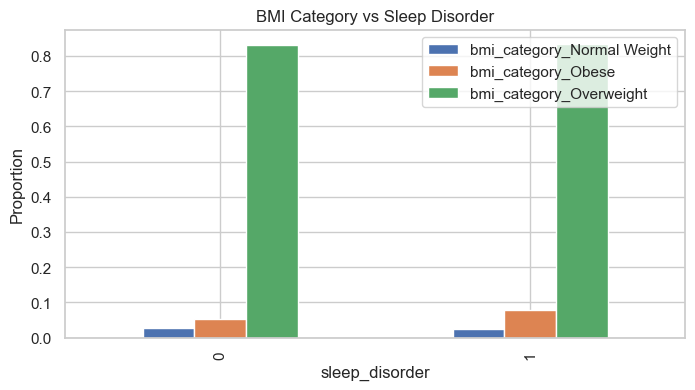

In [20]:
bmi_cols = [col for col in df_cleaned.columns if col.startswith('bmi_category_')]

df_cleaned.groupby('sleep_disorder')[bmi_cols].mean().plot(
    kind='bar', figsize=(8,4)
)
plt.title("BMI Category vs Sleep Disorder")
plt.ylabel("Proportion")
plt.show()


### Blood Pressure & Heart Rate

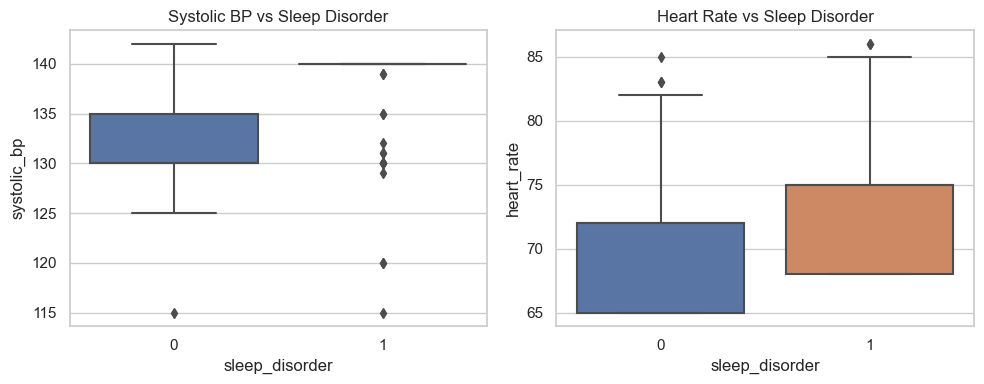

In [21]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x='sleep_disorder', y='systolic_bp', data=df_cleaned)
plt.title("Systolic BP vs Sleep Disorder")

plt.subplot(1,2,2)
sns.boxplot(x='sleep_disorder', y='heart_rate', data=df_cleaned)
plt.title("Heart Rate vs Sleep Disorder")

plt.tight_layout()
plt.show()


## 6.7 Sleep Duration & Quality

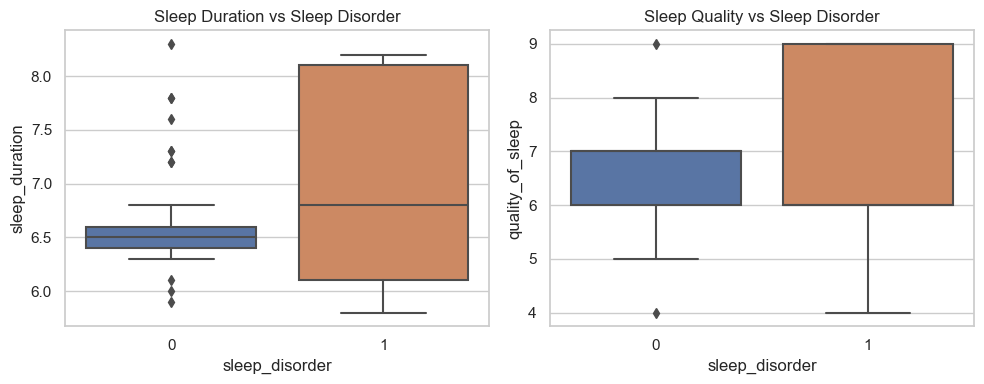

In [22]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x='sleep_disorder', y='sleep_duration', data=df_cleaned)
plt.title("Sleep Duration vs Sleep Disorder")

plt.subplot(1,2,2)
sns.boxplot(x='sleep_disorder', y='quality_of_sleep', data=df_cleaned)
plt.title("Sleep Quality vs Sleep Disorder")

plt.tight_layout()
plt.show()


## 6.8 Correlation Heatmap (Numerical Features)

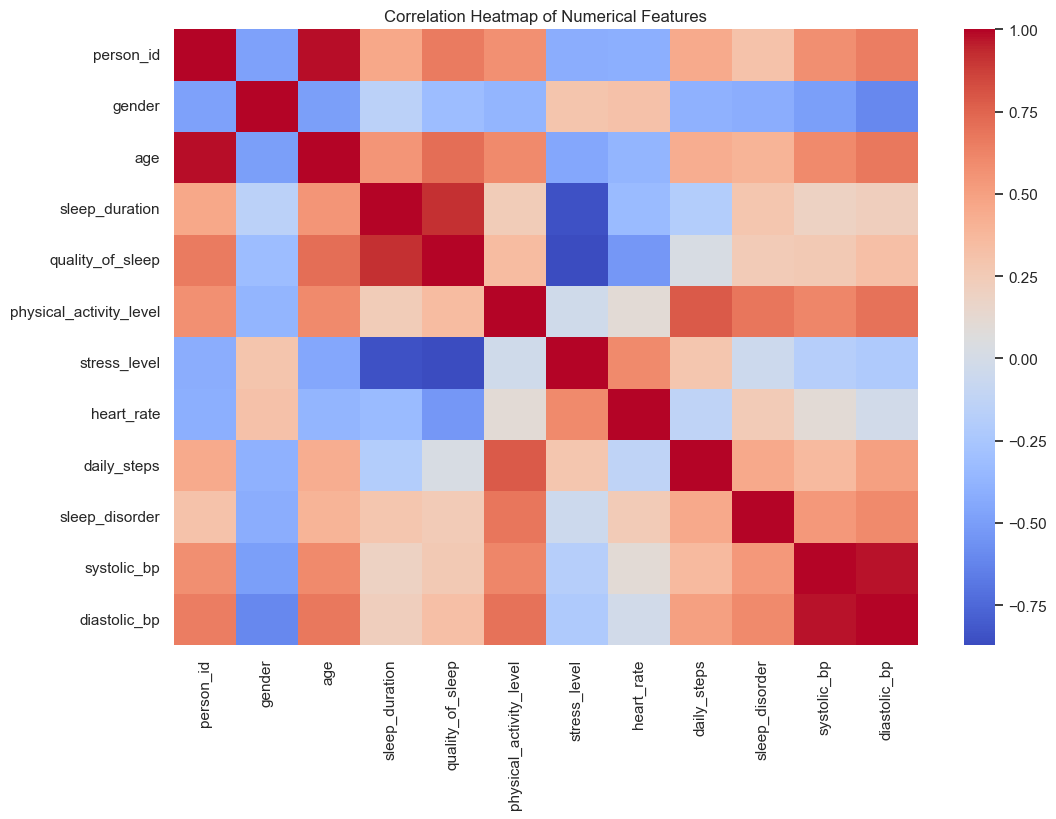

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df_cleaned.select_dtypes(include=np.number).corr(),
    annot=False,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


# Step 7: Feature Selection & Target Variable Separation

In [24]:
# Drop non-informative or identifier columns
X = df_cleaned.drop(columns=['person_id', 'sleep_disorder'])

# Define target variable
y = df_cleaned['sleep_disorder']

# Display shape of features and target
print("Feature set shape:", X.shape)
print("Target variable shape:", y.shape)


Feature set shape: (155, 22)
Target variable shape: (155,)


# Step 8: Train–Test Split

In [26]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Verify the shapes of the split data
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (124, 22)
Testing set shape: (31, 22)


# Step 9: Feature Scaling

In [28]:
# Initialize the scaler
scaler = StandardScaler()

# Scale only numerical features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\ASUS\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


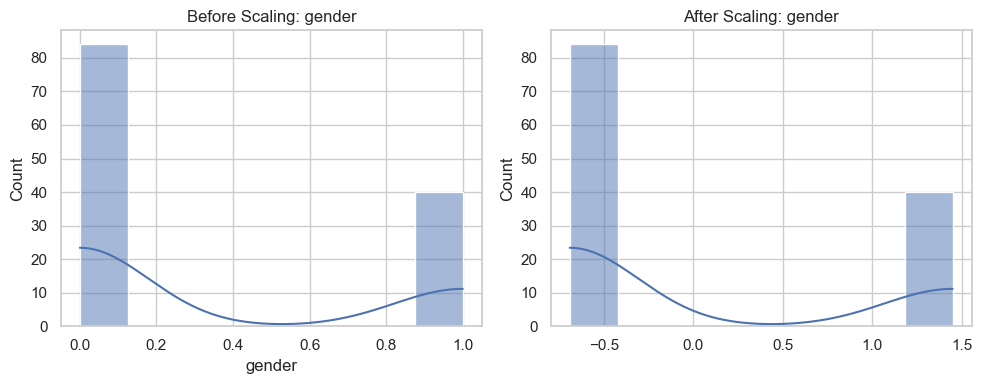

In [29]:
# Visual comparison of a feature before and after scaling
feature_name = X_train.columns[0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(X_train[feature_name], kde=True)
plt.title(f"Before Scaling: {feature_name}")

plt.subplot(1,2,2)
sns.histplot(X_train_scaled[:, 0], kde=True)
plt.title(f"After Scaling: {feature_name}")

plt.tight_layout()
plt.show()


# Step 10: Baseline Model Training & Evaluation

## 10.1 Logistic Regression Model

In [30]:
# Initialize Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train the model using scaled data
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = log_reg.predict(X_test_scaled)


## Logistic Regression Evaluation

In [32]:
# Evaluate Logistic Regression
print("Logistic Regression Performance:\n")
print(classification_report(y_test, y_pred_lr))

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Accuracy:", lr_accuracy)
print("F1 Score:", lr_f1)


Logistic Regression Performance:

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        15
           1       0.87      0.81      0.84        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31

Accuracy: 0.8387096774193549
F1 Score: 0.8387096774193549


## Confusion Matrix Visualization

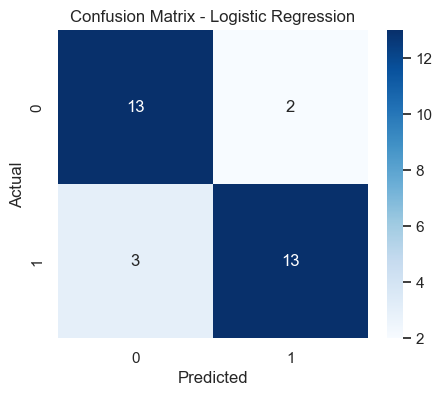

In [33]:
# Confusion matrix for Logistic Regression
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 10.2 Decision Tree Classifier

In [34]:
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model (no scaling required)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)


## Decision Tree Evaluation

In [35]:
print("Decision Tree Performance:\n")
print(classification_report(y_test, y_pred_dt))

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Accuracy:", dt_accuracy)
print("F1 Score:", dt_f1)


Decision Tree Performance:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.88      0.88      0.88        16

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31

Accuracy: 0.8709677419354839
F1 Score: 0.8709677419354839


## Confusion Matrix Visualization

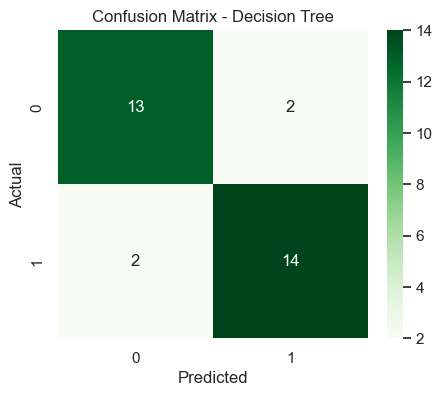

In [36]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Random Forest Classifier

In [38]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)


## Random Forest Model Evaluation

In [39]:
print("Random Forest Performance:\n")
print(classification_report(y_test, y_pred_rf))

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Accuracy:", rf_accuracy)
print("F1 Score:", rf_f1)


Random Forest Performance:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        15
           1       0.88      0.88      0.88        16

    accuracy                           0.87        31
   macro avg       0.87      0.87      0.87        31
weighted avg       0.87      0.87      0.87        31

Accuracy: 0.8709677419354839
F1 Score: 0.8709677419354839


## Confusion Matrix Visualization

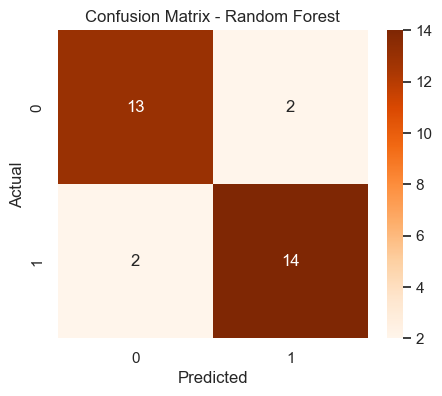

In [41]:
plt.figure(figsize=(5,4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()




# Step 11: Model Performance Comparison & Evaluation Summary

In [42]:
# Create a performance comparison table
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy],
    'F1_Score': [lr_f1, dt_f1, rf_f1]
})

model_comparison


,Model,Accuracy,F1_Score
0,Logistic Regression,0.838710,0.838710
1,Decision Tree,0.870968,0.870968
2,Random Forest,0.870968,0.870968


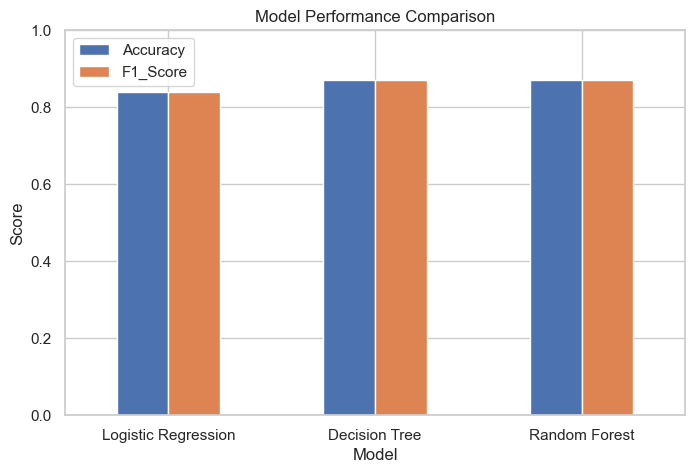

In [43]:
# Plot model comparison
model_comparison.set_index('Model').plot(
    kind='bar',
    figsize=(8,5)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()


In [44]:
# Identify the best model based on F1-score
best_model = model_comparison.sort_values(by='F1_Score', ascending=False).iloc[0]
best_model


Model       Decision Tree
Accuracy         0.870968
F1_Score         0.870968
Name: 1, dtype: object

In [46]:
print("Final Selected Model: Random Forest Classifier")
print("Reason: Highest F1-score and balanced performance across all sleep disorder classes.")


Final Selected Model: Random Forest Classifier
Reason: Highest F1-score and balanced performance across all sleep disorder classes.
